# In-Class Assignment 3

_Thursday, September 3, 2026_

_How to use this notebook:_ 

**Locally**: Hover over the download symbol then to the `ipynb` option then **right-click** to _Save Link As_ to download the file. You can then open the notebook using `jupyter notebook ica3.ipynb` in your terminal.

**Remote**: You can open the notebook on Colab by hovering over the rocket symbol then select launch to colab. In doing so, any data needed for the plots can be click and dragged to the online workbook. By default, the file will go to `/content/` or `/content/sample_data`

**Credit: These exercises follow from work by Mike Zingale's computational lectures.**

---

## Exploring Equation of State Regimes and Pressure Sources

**Work in groups of 3/4**

## Learning Objectives
* explore EOS regimes
* label various EOS regimes
* plot stellar models on EOS regimes
* compare various pressure contriutions on the main-sequence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Physical constants, all in CGS

In [2]:
m_e = 9.11e-28
m_u = 1.66e-24
c = 3.e10
k = 1.38e-16
h = 6.63e-27
a = 5.67e-15
e = 4.8e-10 # esu

# crystallization
Gamma_C = 170

## EOS regimes

We can look at the $\rho$-$T$ plane to understand where each of the components of the EOS
dominate.

Some composition info.  We'll specify

$$\mu_e = \left [ \sum_k \frac{Z_k X_k}{A_k} \right ]^{-1}$$

$$\mu_I = \left [ \sum_k \frac{X_k}{A_k} \right ]^{-1}$$

and $\mu$ such that 

$$\frac{1}{\mu} = \frac{1}{\mu_e} + \frac{1}{\mu_I}$$

We will equate the pressure to compute EOS boundaries and label them. 

In [3]:
mu_e = 2
mu_I = 1.0

mu = 1.0 / (1.0/mu_e + 1.0/mu_I)

Z = 1.0

## Electron degeneracy vs. Ideal gas Boundary

We find the (dimensionless) Fermi momentum ($x_F = p_F / (mc)$) via

$$n_e = \frac{\rho}{\mu_e m_u} = \int_0^{x_F} x^2 dx$$

where we assume complete degeneracy (so the distribution function is just a step-function).  This gives

$$x_F = \left ( \frac{\rho}{\mu_e B} \right )^{1/3}$$

where the constant $B$ is:

$$B = \frac{8\pi}{3} m_u \left (\frac{m_e c}{h} \right )^3$$

We then define the transition to degeracy by comparing to the thermal energy, $k T$

$$E_F = m_e c^2 \left ( \sqrt{1 + x_F^2} - 1 \right ) \sim k T$$

Here's a function that computes this line

In [4]:
# Fermi momentum constant (from number density integral)
B = (8.0*np.pi/3.0)*m_u*(m_e*c/h)**3

def deg_ideal(rho, mu_e=2.0):
    """temperature on the line separating degeneracy and ideal gas as a function
 of rho"""

    # dimensionless Fermi momentum
    x_F = (rho / mu_e / B)**(1./3.)

    # set E_F = k T
    T = (1./k) * m_e * c**2 * (np.sqrt(1 + x_F**2) - 1)

    return T

## Ideal gas vs. radiation-dominated boundary

A simple way to determine whether an ideal case or radiation dominates is to set their energy densities equal.
At the temperatures where we expect this to occur, we will assume that the electrons are not degenerate,
so we will use the full $\mu$ for the composition in the ideal gas instead of $\mu_I$.

Our line is:

$$\frac{\rho k T}{\mu m_u} \sim \frac{1}{3}a T^4$$

Here's a function that computes this

In [5]:
def rad_ideal(rho, mu=0.5):
    """temperature on the line separating radiation and ideal gas as a function 
of rho"""

    T = ((3 * k / (m_u * a)) * (rho / mu))**(1./3.)
    return T

## Crystallization Regime

Finally, at low temperatures and high densities, the ions can crystalize.  The comparison where is the thermal energy to the Coulomb energy:

$$\Gamma = \frac{kT}{Z^2 e^2 / a}$$

where we take $\Gamma = 170$ as the point where crystalization sets in.

The separation between ions, $a$ is found via:

$$V = n_I^{-1} = \frac{\mu_I m_u}{\rho} = \frac{4\pi}{3} a^3$$

Putting this together, the expression for the boundary of crystalization is computed below

In [6]:
def crystallization(rho):
    """temperature where crystallization of ions sets in"""

    T = ((rho / mu_I) * (Z**2 * e**2 / (Gamma_C * k))**3 * (4.0 * np.pi / 3.0 / 
m_u))**(1./3.)
    return T

# a. - Describing the various Equation of State Regimes using a $T-\rho$ Diagram

### **Individually/with the person next to you**:

#### Plotting
1. Plot the **radiation-dominated vs. ideal gas-dominated** region $T$ boundary as a function of density $\rho$.

2. Plot the **electron degenerate-dominated vs. ideal gas-dominated** region $T$ boundary as a function of density $\rho$.

3. Plot the **crystallization** region $T$ boundary as a function of density $\rho$.

#### Labeling
4. Label the **radiation-dominated region** _and_ also label that region with the equation for the pressure $P_{\rm{rad}}$ in that region. 

> Hint: we have not discussed it yet in detail yet but Eqn. 3.44 in [Pols, Chapter 3](https://www.astro.ru.nl/~onnop/education/stev_utrecht_notes/chapter1-4.pdf) will help.

5. Label the **ideal gas-dominated region** _and_ also label that region with the equation for the pressure $P_{\rm{ideal}}$ in that region. 


6. Label the **electron degenerate gas-dominated region** _and_ also label that region with the equation for the pressure $P_{\rm{e},classical}$ in that region. 

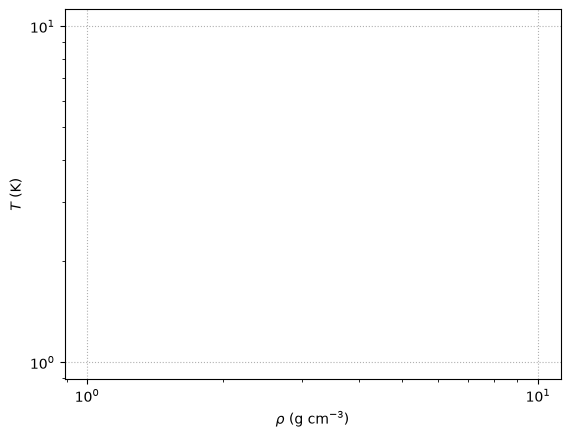

In [7]:
# create an array of densities over which we will plot
rho = np.logspace(-5, 10, 2000)

fig = plt.figure()
ax = fig.add_subplot(111)

# plot the three boundary lines here
#ax.plot(rho, FUNC1(rho))
#ax.plot(rho, FUNC2(rho))
#ax.plot(rho, FUNC3(rho))

# label / annotate here
#ax.text(1.e-2, 1.e9, "BLANK\ndominates", horizontalalignment="center")
#ax.text(1.e-2, 4e8, r"$P_{\rm{BLANK}}=$", horizontalalignment="center")


#ax.text(1.e-3, 1.e5, "BLANK dominates", horizontalalignment="center")
#ax.text(1.e-3, 4.e4, r"$P_{\rm{BLANK}}$", horizontalalignment="center")

#ax.text(1.e3, 1.e5, "BLANK", horizontalalignment="center")
#ax.text(5.e4, 5.e6, r"$P_{BLANK}$", horizontalalignment="center")


#ax.text(3.e5, 1.e3, "$BLANK dominates", horizontalalignment="center")


#plt.title(r'(Mostly) Classic description of various stellar equation of state regimes')


# label the Sun on this diagram using the central density temperatures of the Sun
# solar cheat sheet lives here :https://solar-center.stanford.edu/vitalstats.html
#ax.text(rhoc_sun, tc_sun, "⊙",color='orange',fontsize=22)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\rho~ (\rm{g} \ \rm{cm}^{-3}$)")
ax.set_ylabel("$T$ (K)")
ax.grid(ls=":")

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Which EOS best describes the central conditions of the Sun?

    Your groups thoughtful response.

> Will the Sun always obey the ideal gas law in the center? Or, will a different description become necessary at later times?

    Your groups thoughtful response.
> Will the same equation of state be the same throughout the entire star for a star like the Sun on the main sequence? What about for more massive stars? 

    > Hint: See Figure 3.4 of (Pols)[https://www.astro.ru.nl/~onnop/education/stev_utrecht_notes/chapter1-4.pdf]

    Your groups thoughtful response.

## b. Plotting MESA History data and EOS regimes

### **Individually/with the person next to you**:

#### **Download or reuse**
The model files are again:

* $1 M_\odot$: [M1_default_trimmed_history.data](data/M1_default_trimmed_history.data)

* $15 M_\odot$: [M15_aprox21_trimmed_history.data](data/M15_aprox21_trimmed_history.data)

#### Copy

1. Copy the completed and labeled plot from a. and use here below. We will add to this plot. 

#### Load the MESA history (time evolution properties of quantities, as opposed to _profiles_)
2. load the MESA data using pandas 
3. load the log central temperature and log central density history data for both models

#### Plot and Label

4. Plot and label the $1M_{\odot}$ and $15M_{\odot}$ models.

In [8]:
import pandas as pd
#one_m_sun = pd.read_csv('/path/to/data/file',sep=r'\s+',header=4)
#fifteen_m_sun = pd.read_csv('/path/to/data/',sep=r'\s+',header=4)
#one_m_sun.columns

In [9]:
# import T_center and Rho_center history data
#one_m_sun_rho = one_m_sun['log_center_VAR']
#one_m_sun_T= one_m_sun['log_center_VAR']

#fifteen_m_sun_rho = fifteen_m_sun['log_center_VAR']
#fifteen_m_sun_T= fifteen_m_sun['log_center_VAR']

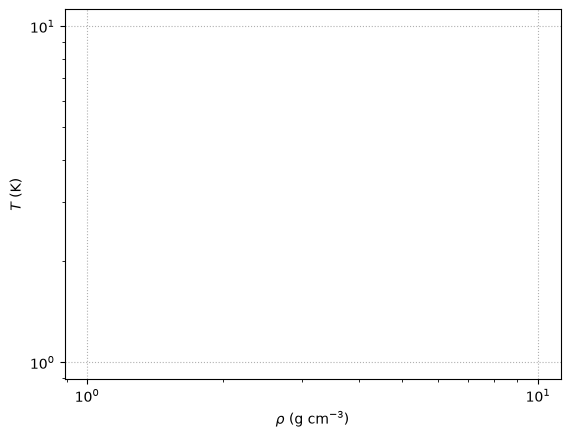

In [10]:
# create an array of densities over which we will plot
rho = np.logspace(-5, 10, 2000)

fig = plt.figure()
ax = fig.add_subplot(111)

# plot the three boundary lines here
#ax.plot(rho, FUNC1(rho))
#ax.plot(rho, FUNC2(rho))
#ax.plot(rho, FUNC3(rho))

# now, add mesa data here for Tc, Rhoc
#ax.plot(10**(one_m_sun_DENSITY),10**(one_m_sun_TC),label='1$M_{\odot}$',color='lightseagreen',ls='-.')
#ax.plot(10**(fifteen_m_sun_DENSITY),10**(fifteen_m_sun_TC),label='15$M_{\odot}$',color='dodgerblue',ls='-.')

# label / annotate here
#ax.text(1.e-2, 1.e9, "BLANK\ndominates", horizontalalignment="center")
#ax.text(1.e-2, 4e8, r"$P_{\rm{BLANK}}=$", horizontalalignment="center")


#ax.text(1.e-3, 1.e5, "BLANK dominates", horizontalalignment="center")
#ax.text(1.e-3, 4.e4, r"$P_{\rm{BLANK}}$", horizontalalignment="center")

#ax.text(1.e3, 1.e5, "BLANK", horizontalalignment="center")
#ax.text(5.e4, 5.e6, r"$P_{BLANK}$", horizontalalignment="center")


#ax.text(3.e5, 1.e3, "$BLANK dominates", horizontalalignment="center")


#plt.title(r'(Mostly) Classic description of various stellar equation of state regimes')


# label the Sun on this diagram using the central density temperatures of the Sun
# solar cheat sheet lives here :https://solar-center.stanford.edu/vitalstats.html
#ax.text(rhoc_sun, tc_sun, "⊙",color='orange',fontsize=22)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\rho~ (\rm{g} \ \rm{cm}^{-3}$)")
ax.set_ylabel("$T$ (K)")
ax.grid(ls=":")

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Which EOS best describes the central conditions of the two stellar models for the low $T$, $\rho$ evolutionary phases?

    Your groups thoughtful response.

> Which EOS regime do they eventually transition to and why might this be?

    Your groups thoughtful response.

> When in a particular regime, can the star have pressure contributions from other regions?

    Your groups thoughtful response.
    
> The two stellar tracks behave differently in the electron degenerate regime, namely, the 1M model eventually vertically. Why might this be? Recall our equation for $P_{e,classical}$ has a dependence on $\rho$.

    Your groups thoughtful response.